# Regression-discontinuity application

The main analysis forms \(K=70\) random assignment statistics
plus one observed statistic per quasi-experiment. Consequently,
the pooled grid contains \(m(K+1)\) values.


In [1]:
from pathlib import Path
import sys


def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "src" / "cp_lfdr").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root containing src/cp_lfdr."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

# Edit DATA_DIR here if the data live outside the repository.
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
SEED = 0
SAVE_FIGURES = True
SAVE_TEX = True
RESULTS_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, stem):
    """Save a publication PDF and a high-resolution PNG.

    Set SAVE_FIGURES=False above to disable both. Set SAVE_TEX=True
    to additionally create a PGF-backed .tex file.
    """
    if not SAVE_FIGURES:
        return []
    paths = [
        FIGURE_DIR / f"{stem}.pdf",
        FIGURE_DIR / f"{stem}.png",
    ]
    fig.savefig(paths[0], bbox_inches="tight")
    fig.savefig(paths[1], bbox_inches="tight", dpi=300)
    if SAVE_TEX:
        tex_path = FIGURE_DIR / f"{stem}.tex"
        fig.savefig(tex_path, format="pgf", bbox_inches="tight")
        paths.append(tex_path)
    print(
        "Saved figure:",
        ", ".join(
            str(path.relative_to(PROJECT_ROOT)) for path in paths
        ),
    )
    return paths


from math import comb

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdrobust import rdrobust

from cp_lfdr.discrete import gamma_from_block_pvalues
from cp_lfdr.multiple_testing import bh_procedure, sl_procedure
from cp_lfdr.rd import (
    compute_pvalues_window,
    filter_local_designs,
)

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 2.2,
})



## Load and prepare the replication data


In [2]:
rd_path = DATA_DIR / "raw" / "rd" / "data-AER-3.dta"
if not rd_path.exists():
    raise FileNotFoundError(
        f"Missing {rd_path}. Follow data/README.md before running."
    )

rd_data = pd.read_stata(rd_path)
rd_data = rd_data.dropna(subset=["bcg"]).drop(columns=["survey"])
rd_data[["town", "z", "Y"]] = (
    rd_data["uazY"]
    .str.extract(r"(\d+)z(\d+)Y(\d+)")
    .astype(int)
)
rd_data["town_z"] = (
    rd_data["town"].astype(str) + "_" + rd_data["z"].astype(str)
)
rd_data["dzag"] = rd_data["dzag"].round(2)
rd_data = rd_data[rd_data["dzag"] != 0].copy()
print(f"Loaded {len(rd_data):,} student records.")


Loaded 6,165,081 student records.


In [3]:
bandwidth = 0.05
analysis_data = filter_local_designs(
    rd_data,
    level="town_z",
    distance_column="dzag",
    bandwidth=bandwidth,
    minimum_per_side=4,
    maximum_total=20,
)
print(
    f"{analysis_data['town_z'].nunique()} quasi-experiments "
    "remain after filtering."
)


345 quasi-experiments remain after filtering.


## Main pooled permutation analysis


In [4]:
alpha = 0.2
dcp_draws = comb(8, 4)
# Each control is sampled independently, with replacement across draws.
# RandomState reproduces the legacy np.random.seed(0) stream.
rng = np.random.RandomState(SEED)
(
    rd_results,
    gammas,
    sorted_pool,
    block_matrix,
    block_pvalues,
    exact_statistics,
    observed_statistics,
) = compute_pvalues_window(
    analysis_data,
    "bcg",
    level="town_z",
    alpha=alpha,
    test_stat="welch_p",
    dcp_draws=dcp_draws,
    rng=rng,
    distance_column="dzag",
    bw_l=bandwidth,
    bw_r=bandwidth,
    gamma_hat=True,
    return_structures=True,
)
gamma, gamma_minus, gamma_bh = gammas
print(
    f"gamma={gamma:.8f}, gamma_minus={gamma_minus:.8f}, "
    f"gamma_BH={gamma_bh:.8f}"
)
print(
    "SL rejections at alpha=0.2:",
    sl_procedure(rd_results["compound_p"], alpha)[1],
)
rd_results.nsmallest(10, "compound_p")


gamma=0.32394366, gamma_minus=0.04225352, gamma_BH=0.04225352
SL rejections at alpha=0.2: 5


,town_z,local_p,compound_p
89,139820_2,0.003788,0.001551
87,13677_4,0.001166,0.001878
308,86829_11,0.004762,0.002368
225,51065_1,0.003584,0.002449
25,110072_4,0.003788,0.002735
136,156810_1,0.001998,0.005511
100,143691_1,0.014286,0.006981
76,13631_13,0.008204,0.009920
83,136606_1,0.008484,0.011431
234,55017_7,0.023810,0.014860


## Plots

### Main rejection curves


Saved figure: results/figures/rd_rejection_curves.pdf, results/figures/rd_rejection_curves.png, results/figures/rd_rejection_curves.tex


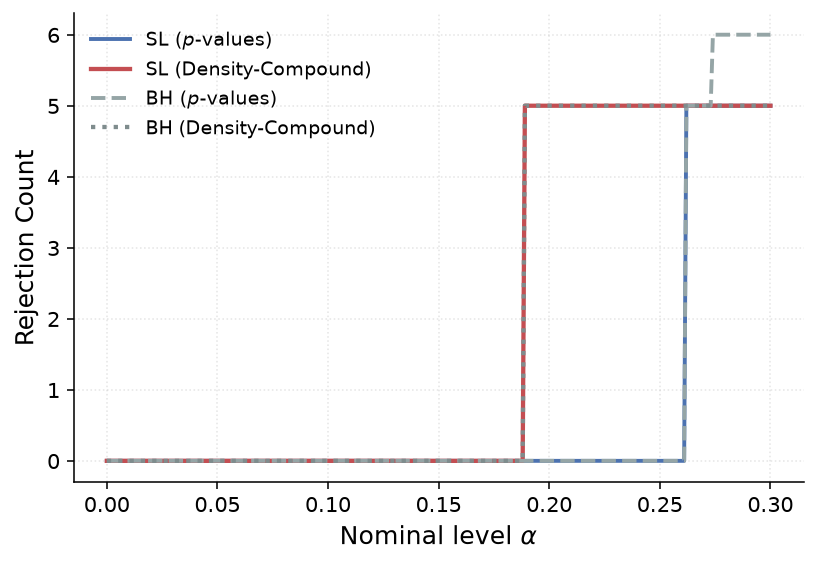

In [5]:
alpha_grid = np.arange(0, 0.301, 0.001)
p_values = rd_results["local_p"].to_numpy()
compound_pvalues = rd_results["compound_p"].to_numpy()
level_ids = list(observed_statistics)
exact_compound_pvalues = np.array(
    [
        np.mean(
            [
                np.mean(
                    exact_statistics[other_id]
                    >= observed_statistics[level_id]
                )
                for other_id in level_ids
            ]
        )
        for level_id in level_ids
    ]
)
rejection_curve = pd.DataFrame(
    [
        {
            "alpha": level,
            "SL permutation": sl_procedure(p_values, level)[1],
            "SL permutation-DCP": sl_procedure(
                compound_pvalues,
                level,
            )[1],
            "BH permutation": bh_procedure(p_values, level)[1],
            "BH permutation-DCP": bh_procedure(
                compound_pvalues,
                level,
            )[1],
            "SL exact compound": sl_procedure(
                exact_compound_pvalues,
                level,
            )[1],
        }
        for level in alpha_grid
    ]
)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(
    rejection_curve["alpha"],
    rejection_curve["SL permutation"],
    color="#4C72B0",
    linestyle="-",
    linewidth=2.0,
    label=r"SL ($p$-values)",
)
ax.plot(
    rejection_curve["alpha"],
    rejection_curve["SL permutation-DCP"],
    color="#C44E52",
    linestyle="-",
    linewidth=2.2,
    label="SL (Density-Compound)",
)
ax.plot(
    rejection_curve["alpha"],
    rejection_curve["BH permutation"],
    color="#95a5a6",
    linestyle="--",
    linewidth=2.0,
    label=r"BH ($p$-values)",
)
ax.plot(
    rejection_curve["alpha"],
    rejection_curve["BH permutation-DCP"],
    color="#7f8c8d",
    linestyle=":",
    linewidth=2.2,
    label="BH (Density-Compound)",
)
ax.set_xlabel(r"Nominal level $\alpha$")
ax.set_ylabel("Rejection Count")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
    color="#cccccc",
    zorder=0,
)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper left", fontsize="small")
fig.tight_layout()
_ = save_figure(fig, "rd_rejection_curves")


### Local RD fits


Mass points detected in the running variable.
Mass points detected in the running variable.


Saved figure: results/figures/rd_local_fits.pdf, results/figures/rd_local_fits.png, results/figures/rd_local_fits.tex


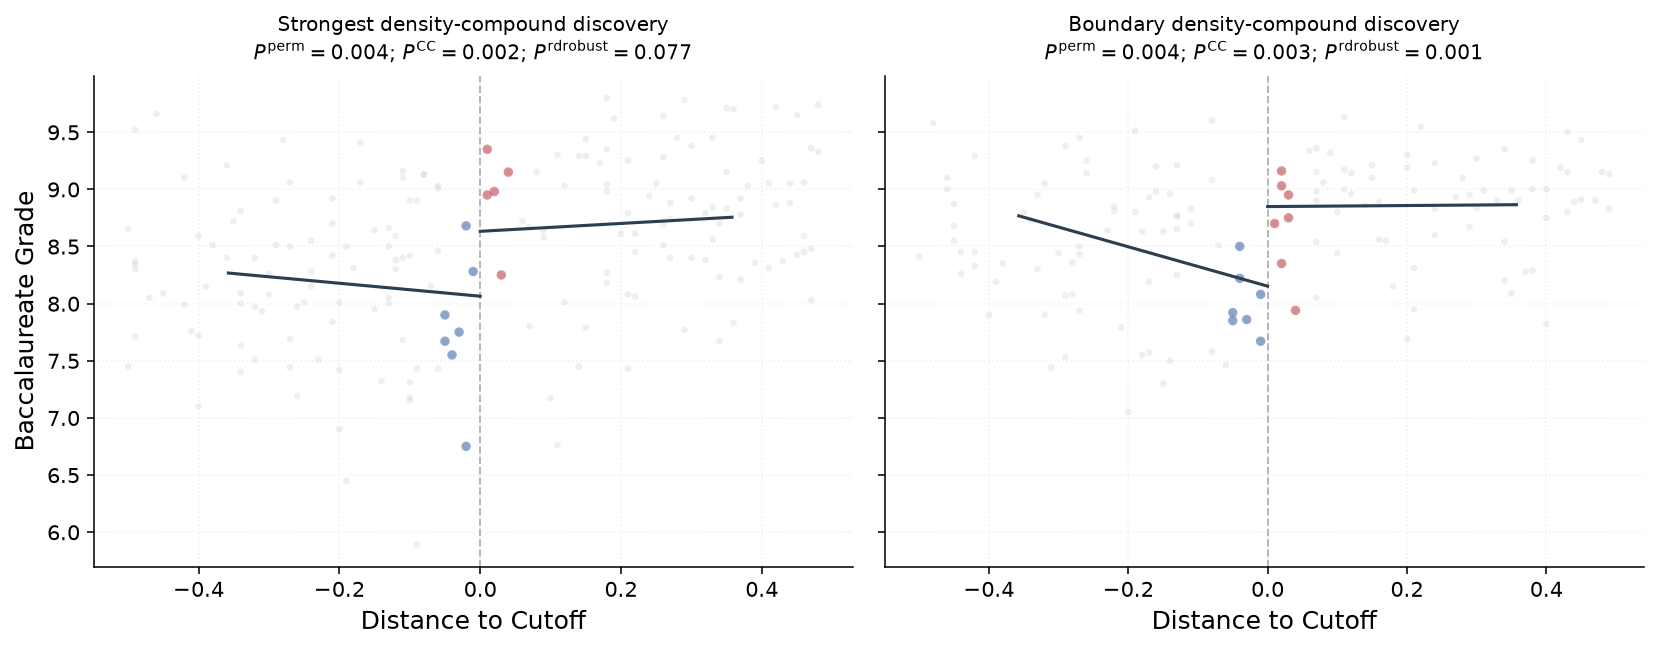

In [6]:
plot_level = "town_z"
target = "bcg"
window_bandwidth = 0.5
rejected_indices, _ = sl_procedure(
    rd_results["compound_p"].to_numpy(), alpha
)
rejected_results = (
    rd_results.iloc[rejected_indices]
    .sort_values("compound_p")
)
if len(rejected_results) < 2:
    raise RuntimeError(
        "At least two density-compound discoveries are required "
        "for the local-RD comparison."
    )
target_units = [
    rejected_results.iloc[0][plot_level],
    rejected_results.iloc[-1][plot_level],
]
panel_descriptions = [
    "Strongest density-compound discovery",
    "Boundary density-compound discovery",
]


def format_pvalue(value):
    return r"<0.001" if value < 0.001 else f"={value:.3f}"

fig, axes = plt.subplots(
    1,
    len(target_units),
    figsize=(12, 4.8),
    sharey=True,
)
axes = np.atleast_1d(axes)
data_full = rd_data.copy()

for ax, unit_id, panel_description in zip(
    axes, target_units, panel_descriptions
):
    unit_data = data_full[
        data_full[plot_level] == unit_id
    ].copy()
    unit_data = unit_data[
        unit_data["dzag"].round(2) != 0
    ].copy()
    robust_fit = rdrobust(
        y=unit_data[target],
        x=unit_data["dzag"],
        cluster=unit_data["sid2"],
        vce="cr3",
    )
    robust_pvalue = robust_fit.pv.loc["Robust", "P>|z|"]
    statistics = rd_results.loc[
        rd_results[plot_level] == unit_id
    ].iloc[0]
    display_window = unit_data[
        unit_data["dzag"].abs() <= window_bandwidth
    ].copy()
    left_window = unit_data[
        (unit_data["dzag"] < 0)
        & (unit_data["dzag"] >= -bandwidth)
    ].copy()
    right_window = unit_data[
        (unit_data["dzag"] > 0)
        & (unit_data["dzag"] <= bandwidth)
    ].copy()

    ax.scatter(
        display_window["dzag"],
        display_window[target],
        color="#bdc3c7",
        alpha=0.25,
        s=12,
        edgecolors="none",
        label="Background",
        zorder=1,
        rasterized=True,
    )
    ax.scatter(
        left_window["dzag"],
        left_window[target],
        color="#4C72B0",
        s=24,
        alpha=0.6,
        edgecolors="none",
        label="Left Window",
        zorder=2,
        rasterized=True,
    )
    ax.scatter(
        right_window["dzag"],
        right_window[target],
        color="#C44E52",
        s=24,
        alpha=0.6,
        edgecolors="none",
        label="Right Window",
        zorder=2,
        rasterized=True,
    )

    left_fit_bandwidth = robust_fit.bws.iloc[0, 0]
    right_fit_bandwidth = robust_fit.bws.iloc[0, 1]
    left_coefficients = np.asarray(
        robust_fit.beta_p_l
    ).reshape(-1)
    right_coefficients = np.asarray(
        robust_fit.beta_p_r
    ).reshape(-1)
    x_left = np.linspace(
        max(-window_bandwidth, -left_fit_bandwidth),
        -0.0001,
        100,
    )
    x_right = np.linspace(
        0.0001,
        min(window_bandwidth, right_fit_bandwidth),
        100,
    )
    y_left = sum(
        coefficient * x_left**degree
        for degree, coefficient in enumerate(left_coefficients)
    )
    y_right = sum(
        coefficient * x_right**degree
        for degree, coefficient in enumerate(right_coefficients)
    )
    ax.plot(
        x_left,
        y_left,
        color="#2c3e50",
        linewidth=1.6,
        zorder=3,
    )
    ax.plot(
        x_right,
        y_right,
        color="#2c3e50",
        linewidth=1.6,
        zorder=3,
    )
    ax.axvline(
        0,
        color="#7f8c8d",
        linestyle="--",
        linewidth=1.0,
        alpha=0.6,
    )

    ax.set_title(
        panel_description + "\n"
        + rf"$P^{{\mathrm{{perm}}}}{format_pvalue(statistics['local_p'])}$; "
        + rf"$P^{{\mathrm{{CC}}}}{format_pvalue(statistics['compound_p'])}$; "
        + rf"$P^{{\mathrm{{rdrobust}}}}{format_pvalue(robust_pvalue)}$",
        fontsize=10.5,
        pad=8,
    )
    ax.set_xlabel("Distance to Cutoff")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(
        True,
        linestyle=":",
        alpha=0.3,
        color="#cccccc",
    )
axes[0].set_ylabel("Baccalaureate Grade")
fig.tight_layout()
_ = save_figure(fig, "rd_local_fits")


### Theoretical inflation curve


Saved figure: results/figures/rd_inflation_curve.pdf, results/figures/rd_inflation_curve.png, results/figures/rd_inflation_curve.tex


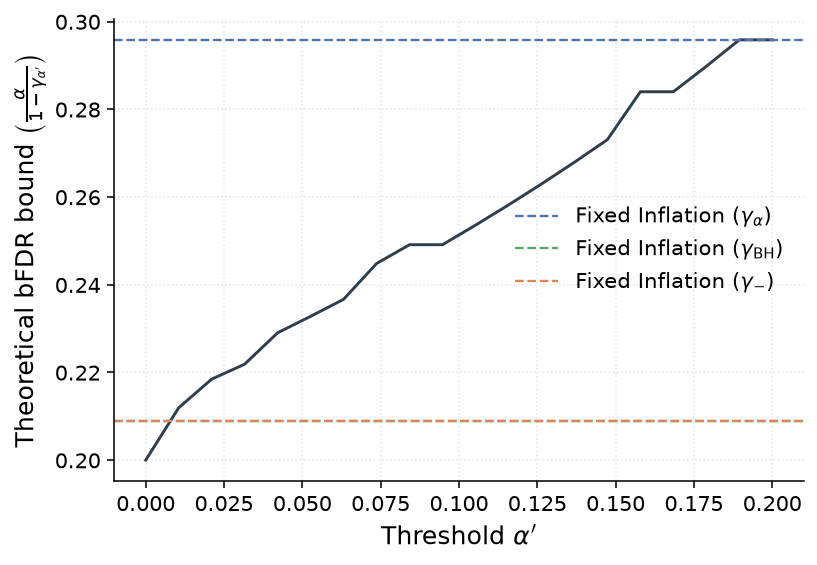

In [7]:
alpha_primes = np.linspace(0, alpha, 20)
gamma_curve = np.array(
    [
        gamma_from_block_pvalues(
            block_pvalues,
            level_value,
        )
        for level_value in alpha_primes
    ]
)
inflation_curve = alpha / (1 - gamma_curve)
inflation_fixed = alpha / (1 - gamma)
inflation_minus = alpha / (1 - gamma_minus)
inflation_bh = alpha / (1 - gamma_bh)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(
    alpha_primes,
    inflation_curve,
    color="#2c3e50",
    linewidth=1.5,
)
ax.axhline(
    inflation_fixed,
    color="#4C72B0",
    linestyle="--",
    linewidth=1.2,
    label=r"Fixed Inflation ($\gamma_\alpha$)",
)
ax.axhline(
    inflation_bh,
    color="#55A868",
    linestyle="--",
    linewidth=1.2,
    label=r"Fixed Inflation ($\gamma_{\mathrm{BH}}$)",
)
ax.axhline(
    inflation_minus,
    color="#DD8452",
    linestyle="--",
    linewidth=1.2,
    label=r"Fixed Inflation ($\gamma_{-}$)",
)

ax.set_xlabel(r"Threshold $\alpha^\prime$")
ax.set_ylabel(
    r"Theoretical bFDR bound $\left(\frac{\alpha}{1-\gamma_{\alpha^\prime}}\right)$"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
    color="#cccccc",
)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="center right")
fig.tight_layout()
_ = save_figure(fig, "rd_inflation_curve")


### P-value distributions


Saved figure: results/figures/rd_pvalue_histogram.pdf, results/figures/rd_pvalue_histogram.png, results/figures/rd_pvalue_histogram.tex
Saved figure: results/figures/rd_qq_tail_plot.pdf, results/figures/rd_qq_tail_plot.png, results/figures/rd_qq_tail_plot.tex


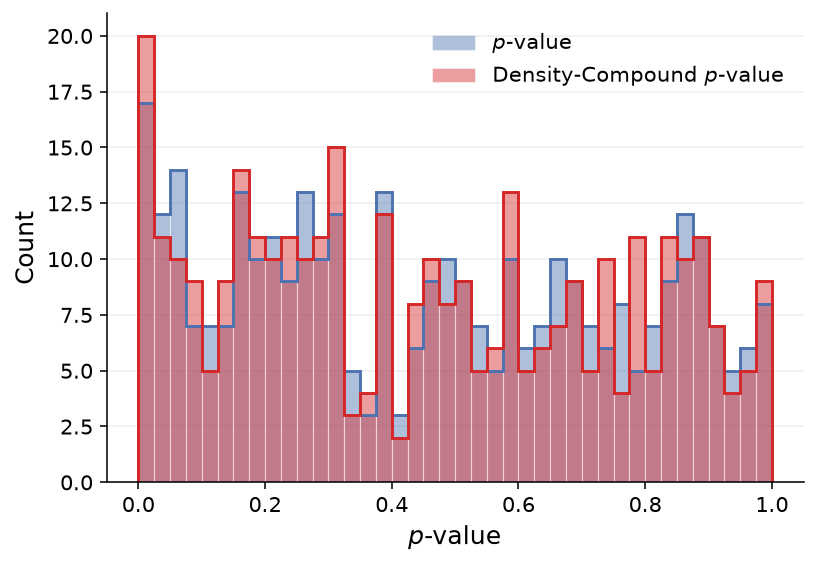

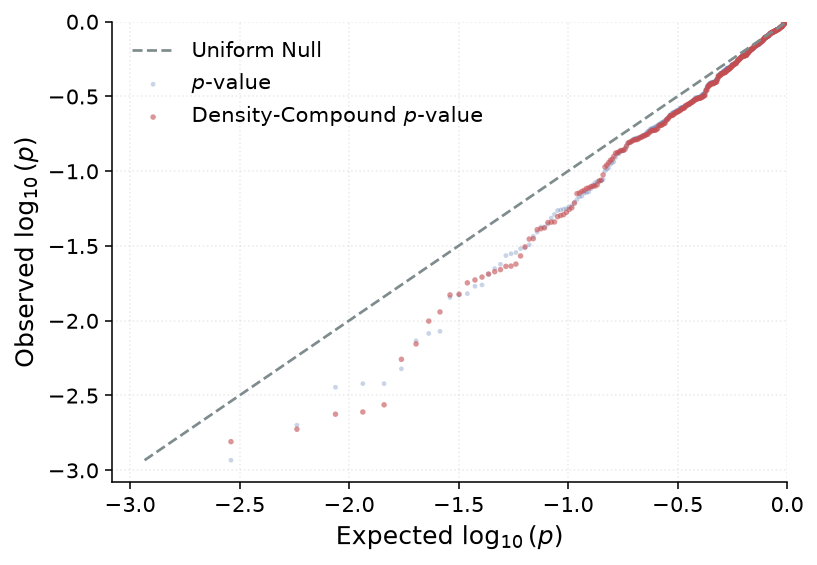

In [8]:
fig, ax = plt.subplots(figsize=(6, 4.2))
bins = np.linspace(0, 1, 41)
ax.hist(
    p_values,
    bins=bins,
    alpha=0.45,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.6,
    label=r"$p$-value",
)
ax.hist(
    compound_pvalues,
    bins=bins,
    alpha=0.45,
    color="#d62728",
    edgecolor="white",
    linewidth=0.6,
    label=r"Density-Compound $p$-value",
)
ax.hist(
    p_values,
    bins=bins,
    histtype="step",
    color="#4C72B0",
    linewidth=1.5,
)
ax.hist(
    compound_pvalues,
    bins=bins,
    histtype="step",
    color="#d62728",
    linewidth=1.5,
)
ax.set_xlabel(r"$p$-value")
ax.set_ylabel("Count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
ax.grid(True, axis="y", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()
save_figure(fig, "rd_pvalue_histogram")

expected = (
    np.arange(1, len(p_values) + 1)
    / (len(p_values) + 1)
)
sorted_pvalues = np.sort(p_values)
sorted_compound = np.sort(compound_pvalues)
minimum = min(
    np.log10(expected).min(),
    np.log10(sorted_pvalues).min(),
    np.log10(sorted_compound).min(),
)
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(
    [minimum, 0],
    [minimum, 0],
    color="#7f8c8d",
    linestyle="--",
    linewidth=1.4,
    label="Uniform Null",
)
ax.scatter(
    np.log10(expected),
    np.log10(sorted_pvalues),
    color="#4C72B0",
    s=6,
    alpha=0.3,
    edgecolors="none",
    label=r"$p$-value",
    rasterized=True,
)
ax.scatter(
    np.log10(expected),
    np.log10(sorted_compound),
    color="#C44E52",
    s=8,
    alpha=0.6,
    edgecolors="none",
    label=r"Density-Compound $p$-value",
    rasterized=True,
)
ax.set_xlabel(r"Expected $\log_{10}(p)$")
ax.set_ylabel(r"Observed $\log_{10}(p)$")
ax.set_xlim(minimum * 1.05, 0)
ax.set_ylim(minimum * 1.05, 0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(
    True,
    linestyle=":",
    alpha=0.4,
    color="#cccccc",
)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
_ = save_figure(fig, "rd_qq_tail_plot")


### Exact separately pooled comparison


Saved figure: results/figures/rd_exact_pool_comparison.pdf, results/figures/rd_exact_pool_comparison.png, results/figures/rd_exact_pool_comparison.tex


Saved figure: results/figures/rd_exact_pool_qq_tail_plot.pdf, results/figures/rd_exact_pool_qq_tail_plot.png, results/figures/rd_exact_pool_qq_tail_plot.tex


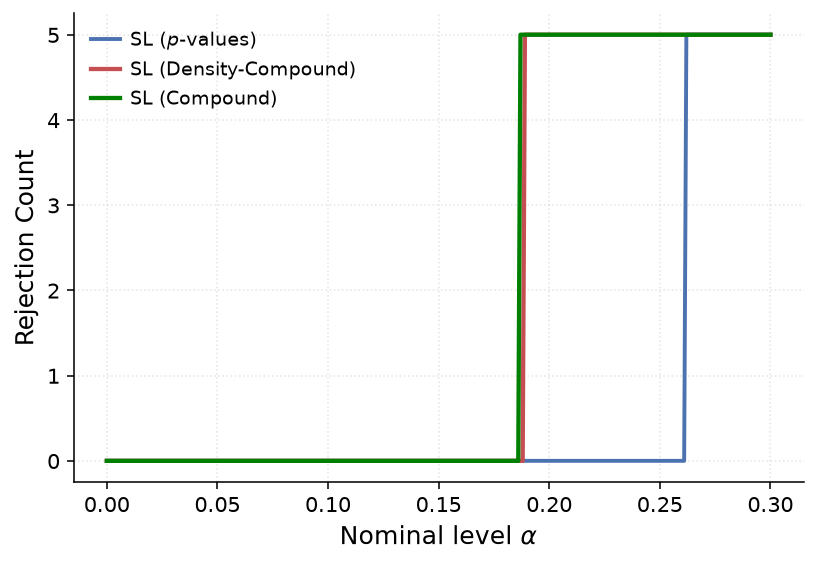

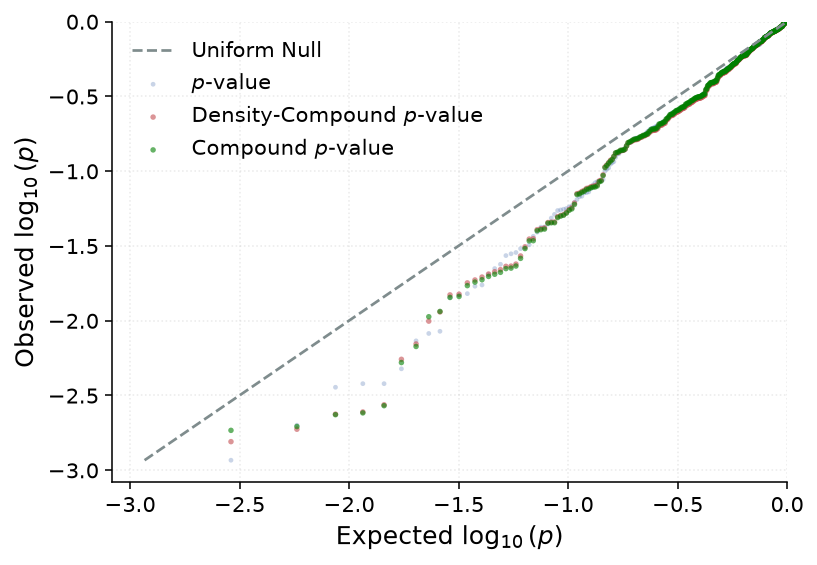

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(
    rejection_curve["alpha"],
    rejection_curve["SL permutation"],
    color="#4C72B0",
    linewidth=2.0,
    label=r"SL ($p$-values)",
)
ax.plot(
    rejection_curve["alpha"],
    rejection_curve["SL permutation-DCP"],
    color="#C44E52",
    linewidth=2.2,
    label="SL (Density-Compound)",
)
ax.plot(
    rejection_curve["alpha"],
    rejection_curve["SL exact compound"],
    color="green",
    linewidth=2.2,
    label="SL (Compound)",
)
ax.set_xlabel(r"Nominal level $\alpha$")
ax.set_ylabel("Rejection Count")
ax.yaxis.set_major_locator(
    plt.MaxNLocator(integer=True)
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(
    True,
    linestyle=":",
    alpha=0.5,
    color="#cccccc",
)
ax.set_axisbelow(True)
ax.legend(
    frameon=False,
    loc="upper left",
    fontsize="small",
    columnspacing=1.2,
    handletextpad=0.5,
    handlelength=1.5,
)
fig.tight_layout()
save_figure(fig, "rd_exact_pool_comparison")

expected = np.arange(1, len(p_values) + 1) / (len(p_values) + 1)
qq_series = [
    (p_values, "#4C72B0", 6, 0.3, r"$p$-value"),
    (
        compound_pvalues,
        "#C44E52",
        8,
        0.6,
        r"Density-Compound $p$-value",
    ),
    (
        exact_compound_pvalues,
        "green",
        8,
        0.6,
        r"Compound $p$-value",
    ),
]
log_expected = np.log10(expected)
log_observed = [np.log10(np.sort(values)) for values, *_ in qq_series]
minimum = min(log_expected.min(), *(values.min() for values in log_observed))

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(
    [minimum, 0],
    [minimum, 0],
    color="#7f8c8d",
    linestyle="--",
    linewidth=1.4,
    label="Uniform Null",
    zorder=3,
)
for observed, (_, color, size, opacity, label) in zip(
    log_observed,
    qq_series,
):
    ax.scatter(
        log_expected,
        observed,
        color=color,
        s=size,
        alpha=opacity,
        edgecolors="none",
        label=label,
        zorder=2,
        rasterized=True,
    )
ax.set_xlabel(r"Expected $\log_{10}(p)$")
ax.set_ylabel(r"Observed $\log_{10}(p)$")
ax.set_xlim(minimum * 1.05, 0)
ax.set_ylim(minimum * 1.05, 0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, linestyle=":", alpha=0.4, color="#cccccc", zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
_ = save_figure(fig, "rd_exact_pool_qq_tail_plot")
